# 焊接工艺参数数据库 → MongoDB 导入管线 (交互版)

本 notebook 是 [`project_data/ingest_mongo.py`](../project_data/ingest_mongo.py) 的交互式版本:
把原始工作簿 `Welding Process Parameter Database 2022_rev.2022.03.24.xlsx` 解析、
构建为 **MongoDB 文档模型**, 写入集合 `welding_dynamics.welding_parameters`,
并在每一步配上**数据质量统计与可视化**。

管线三步 (对应文档 `doc_type`):
1. **解析主表** → `procedure` 文档 (记录级信息 + 内嵌各焊道 `passes`);
2. **摆动库 / 备注** → `weave_pattern` / `source_meta` 文档;
3. **写入 MongoDB** 并建索引, 再查询回来校验。

> ⚠️ 与脚本一致, 写入步骤会 **drop 并重建** 该集合 (幂等)。需本机 `mongod` 运行于 `localhost:27017`。
> 只想读回可视化而不重写, 用 [`welding_parameter_database_exploration.ipynb`](welding_parameter_database_exploration.ipynb)。


In [1]:
import re
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pymongo import MongoClient, ASCENDING

DATA = Path("../project_data/data/Welding Process Parameter Database 2022_rev.2022.03.24.xlsx")
MONGO = "mongodb://localhost:27017"
DB, COLL = "welding_dynamics", "welding_parameters"
assert DATA.exists(), "请从仓库根目录的 notebooks/ 下运行"

# 中文字体 (环境自带 Noto Sans CJK)
matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "SimHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

# 分类色板 (已通过 CVD/对比度校验的参考色板, 按固定顺序取用, 不循环)
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, INK2, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
GOOD, WARN = "#0ca30c", "#eda100"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, fontsize=11, loc="left", pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

def barh(ax, vc, title, color=C[0], fmt="{:.0f}"):
    vc = vc.sort_values()
    ax.barh(vc.index.astype(str), vc.values, color=color, height=0.64)
    for y, v in enumerate(vc.values):
        ax.text(v + max(vc.values) * 0.02, y, fmt.format(v), va="center", color=INK2, fontsize=9)
    ax.set_xlim(0, max(vc.values) * 1.16)
    ax.grid(axis="y", visible=False)
    style_ax(ax, title=title)

## 1. 解析函数

主表数值列格式不一, 与脚本完全一致的四个解析函数:
- `parse_current` — 括号内为实际电流 (林肯主值是送丝设定), 双丝取主丝, 区间取中值;
- `parse_num` — 取首个数值 (电压去单位, 双丝取主丝);
- `clean` — xlsx 单元格 → BSON 兼容标量, 空/`*` → `None`;
- `manufacturer` — 型号串归一到厂商。


In [2]:
NUM = re.compile(r"\d+(?:\.\d+)?")

def parse_current(v):
    if pd.isna(v): return None
    s = str(v).strip().replace("（", "(").replace("）", ")")
    if not s or s == "*": return None
    m = re.search(r"\(([\d.]+)\s*A?\s*\)", s)      # 括号内 = 实际电流
    if m and float(m.group(1)) >= 50: return float(m.group(1))
    m = NUM.search(s.split("/")[0])                     # 双丝取主丝
    if not m: return None
    x = float(m.group(0))
    m2 = re.search(r"-\s*([\d.]+)", s.split("(")[0])  # 区间取中值
    if m2 and float(m2.group(1)) > x: x = (x + float(m2.group(1))) / 2
    return x

def parse_num(v):
    if pd.isna(v): return None
    m = NUM.search(str(v).strip().replace("（", "(").split("/")[0])
    return float(m.group(0)) if m else None

def clean(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return None
    if isinstance(v, (np.integer, np.floating)): v = v.item()
    if isinstance(v, str):
        v = v.strip()
        if v in ("", "*"): return None
    return v

def manufacturer(s):
    for key, name in [("林肯", "Lincoln"), ("奥太", "Aotai"), ("麦格米特", "Megmeet"),
                      ("福尼斯", "Fronius"), ("伏能士", "Fronius"), ("乐驰", "LeChi"),
                      ("乐弛", "LeChi"), ("松下", "Panasonic"), ("米加尼克", "Migatronic")]:
        if key in str(s): return name
    return "other"

# 在几个"棘手"样本上演示解析效果
demo = ["420（280A）", "227A(主送丝速度7.5)/210A(从送丝速度5.5)", "250-260",
        "350（300）", "120-140A（送丝速度0.9-1.2m/min）", "400", "*"]
pd.DataFrame({"current_raw": demo, "→ current_A": [parse_current(x) for x in demo]})

,current_raw,→ current_A
0,420（280A）,280.0
1,227A(主送丝速度7.5)/210A(从送丝速度5.5),227.0
2,250-260,255.0
3,350（300）,300.0
4,120-140A（送丝速度0.9-1.2m/min）,130.0
5,400,400.0
6,*,NaN


## 2. 读取主表 → 构建 `procedure` 文档

主表前 4 行是多级表头 + 填写说明, 数据从第 5 行起; 记录级列 (合并单元格) 前向填充,
每条记录的多行焊道内嵌进 `passes` 数组。逐焊道同时保留**原始串** (`*_raw`) 与**解析值**。


In [3]:
xls = pd.ExcelFile(DATA)
raw = xls.parse("焊接工艺参数", header=None)
df_raw = raw.iloc[4:].reset_index(drop=True)
df_raw["rec_id"] = df_raw[0].notna().cumsum()
REC_COLS = list(range(0, 14)) + list(range(45, 54))
df_raw[REC_COLS] = df_raw[REC_COLS].ffill()

procs = []
for rid, g in df_raw.groupby("rec_id"):
    r = g.iloc[0]
    passes = []
    for _, p in g.iterrows():
        I, U, v = parse_current(p[28]), parse_num(p[29]), parse_num(p[44])
        if U is not None and "一元化" in str(p[29]): U = None
        heat = round(U * I / v, 3) if all(x for x in (I, U, v)) else None  # J/mm, 未乘电弧效率
        passes.append({
            "pass_no": clean(p[14]),
            "current_raw": clean(p[28]), "current_A": I,
            "voltage_raw": clean(p[29]), "voltage_V": U,
            "voltage_synergic": "一元化" in str(p[29]),
            "travel_speed_mm_s": v, "heat_input_J_mm": heat,
            "weave": {"basis": clean(p[40]), "frequency_raw": clean(p[41]),
                      "frequency_Hz": parse_num(p[41]), "amplitude_raw": clean(p[42]),
                      "amplitude_mm": parse_num(p[42]), "file_no": clean(p[43])},
            "arc_start": {"current": clean(p[24]), "voltage": clean(p[25]), "file_no": clean(p[26])},
            "arc_end": {"current": clean(p[32]), "voltage": clean(p[33]), "file_no": clean(p[34])},
            "burnback": {"mode": clean(p[36]), "workpoint": clean(p[37]),
                         "time": clean(p[38]), "file_no": clean(p[39])},
            "multipass_template": {"name": clean(p[13]), "offset_y": clean(p[17]),
                                   "offset_z": clean(p[18]), "start_offset": clean(p[21]),
                                   "end_offset": clean(p[22])},
        })
    procs.append({
        "doc_type": "procedure", "record_id": int(rid),
        "machine": {"model_raw": clean(r[0]), "manufacturer": manufacturer(r[0])},
        "base_metal": clean(r[1]),
        "wire": {"diameter_mm": clean(pd.to_numeric(r[2], errors="coerce")), "type": clean(r[3])},
        "shielding_gas": clean(r[4]),
        "joint": {"seam_type": clean(r[5]), "groove_size": clean(r[7]), "backing": clean(r[8]),
                  "position": clean(r[9]), "leg_size": clean(r[10]),
                  "rx_tilt_deg": clean(pd.to_numeric(r[11], errors="coerce")),
                  "ry_travel_deg": clean(pd.to_numeric(r[12], errors="coerce"))},
        "n_passes": len(passes), "passes": passes,
        "source": {"customer": clean(r[45]), "project_no": clean(r[46]),
                   "stickout_mm": clean(r[47]), "torch": clean(r[48]),
                   "workpiece": clean(r[49]), "submitter": clean(r[50]),
                   "reviewer": clean(r[51]), "entry_date": clean(r[52]), "note": clean(r[53])},
    })

total_passes = sum(d["n_passes"] for d in procs)
print(f"构建 procedure 文档: {len(procs)} 条, 内嵌焊道 {total_passes} 条")

# 展示一个多道焊样本文档 (passes 截断)
sample = next(d for d in procs if d["n_passes"] >= 3)
view = dict(sample); view["passes"] = [sample["passes"][0], f"... 共 {sample['n_passes']} 焊道"]
pprint(view, sort_dicts=False, width=100)

构建 procedure 文档: 130 条, 内嵌焊道 417 条
{'doc_type': 'procedure',
 'record_id': 1,
 'machine': {'model_raw': '林肯R450', 'manufacturer': 'Lincoln'},
 'base_metal': '碳钢',
 'wire': {'diameter_mm': 1.2, 'type': '实芯'},
 'shielding_gas': '82% Ar + 18% CO2',
 'joint': {'seam_type': '角接',
           'groove_size': None,
           'backing': None,
           'position': '平角焊',
           'leg_size': '14*14',
           'rx_tilt_deg': 0,
           'ry_travel_deg': 0},
 'n_passes': 3,
 'passes': [{'pass_no': 0,
             'current_raw': '420（280A）',
             'current_A': 280.0,
             'voltage_raw': 29.5,
             'voltage_V': 29.5,
             'voltage_synergic': False,
             'travel_speed_mm_s': 6.3,
             'heat_input_J_mm': 1311.111,
             'weave': {'basis': None,
                       'frequency_raw': 2,
                       'frequency_Hz': 2.0,
                       'amplitude_raw': 4,
                       'amplitude_mm': 4.0,
                       'f

## 3. 数据质量: 原始格式 与 解析产出

导入的核心价值是把 xlsx 里五花八门的电流写法清洗成数值。左图统计原始 `current_raw` 的格式类别
(解释了为何需要 `parse_current`), 右图统计各焊道字段的**解析产出率** (非空占比)。


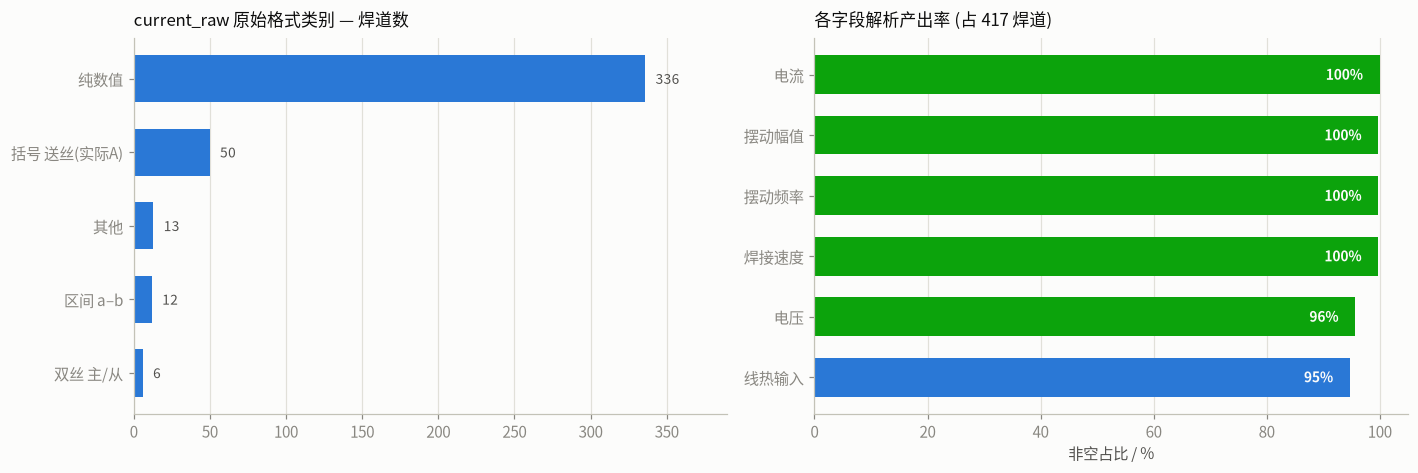

电压解析产出 96%: 其中 15 焊道为电源“一元化/协同”模式 (voltage_V 置空)


In [4]:
pf = pd.json_normalize(
    [{"current_raw": p["current_raw"], "current_A": p["current_A"],
      "voltage_V": p["voltage_V"], "voltage_synergic": p["voltage_synergic"],
      "travel_speed_mm_s": p["travel_speed_mm_s"], "heat_input_J_mm": p["heat_input_J_mm"],
      "frequency_Hz": p["weave"]["frequency_Hz"], "amplitude_mm": p["weave"]["amplitude_mm"]}
     for d in procs for p in d["passes"]])

def current_format(v):
    if v is None or (isinstance(v, float) and pd.isna(v)): return "缺失 / *"
    s = str(v).strip().replace("（", "(").replace("）", ")")
    if s in ("", "*"): return "缺失 / *"
    if "主" in s or "从" in s: return "双丝 主/从"
    if re.search(r"\([\d.]+\s*A?\s*\)", s): return "括号 送丝(实际A)"
    if re.search(r"\d+\s*-\s*\d+", s.split("(")[0]): return "区间 a–b"
    if re.fullmatch(r"[\d.]+\s*[Aa]?", s): return "纯数值"
    return "其他"

fmt = pf["current_raw"].map(current_format).value_counts()

fields = {"current_A": "电流", "voltage_V": "电压", "travel_speed_mm_s": "焊接速度",
          "heat_input_J_mm": "线热输入", "frequency_Hz": "摆动频率", "amplitude_mm": "摆动幅值"}
yield_pct = pd.Series({lbl: pf[c].notna().mean() * 100 for c, lbl in fields.items()})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
barh(axes[0], fmt, "current_raw 原始格式类别 — 焊道数")
yv = yield_pct.sort_values()
colors = [GOOD if v >= 95 else (C[0] if v >= 80 else WARN) for v in yv.values]
axes[1].barh(yv.index, yv.values, color=colors, height=0.64)
for y, v in enumerate(yv.values):
    axes[1].text(v - 3, y, f"{v:.0f}%", va="center", ha="right", color="#fcfcfb", fontsize=9, fontweight="bold")
axes[1].set_xlim(0, 105); axes[1].grid(axis="y", visible=False)
style_ax(axes[1], title=f"各字段解析产出率 (占 {len(pf)} 焊道)", xlabel="非空占比 / %")
fig.tight_layout()
plt.show()

print(f"电压解析产出 {pf['voltage_V'].notna().mean():.0%}: "
      f"其中 {int(pf['voltage_synergic'].sum())} 焊道为电源“一元化/协同”模式 (voltage_V 置空)")

## 4. 摆动库 → `weave_pattern`, 备注 → `source_meta`

摆动库表按路点定义波形 (编号 ffill); 备注表逐行是录入规则。


In [5]:
wl = xls.parse("摆动库参数", header=None).iloc[1:, :10]
wl.columns = ["pattern_id", "point", "time_pct", "x_pct", "y_pct", "z_pct",
              "angle_deg", "current_pct", "voltage_pct", "update"]
wl["pattern_id"] = wl["pattern_id"].ffill()
wl = wl.dropna(subset=["point"])

weaves = []
for pid, g in wl.groupby("pattern_id", sort=False):
    weaves.append({
        "doc_type": "weave_pattern", "pattern_id": int(pid),
        "waypoints": [{k: clean(p[k]) for k in
                       ["point", "time_pct", "x_pct", "y_pct", "z_pct",
                        "angle_deg", "current_pct", "voltage_pct"]}
                      for _, p in g.iterrows()],
    })

notes = [str(x).strip() for x in xls.parse("备注", header=None).iloc[:, 0].dropna()]
source_meta = {"doc_type": "source_meta", "source_file": DATA.name,
               "revision": "2022.03.24", "entry_notes": notes}

docs = procs + weaves + [source_meta]
print(f"weave_pattern: {len(weaves)} 个波形 (路点合计 {sum(len(w['waypoints']) for w in weaves)})")
print(f"source_meta:   1 个 ({len(notes)} 条录入规则)")
print(f"待写入文档总数: {len(docs)}")

weave_pattern: 21 个波形 (路点合计 105)
source_meta:   1 个 (12 条录入规则)
待写入文档总数: 152


## 5. 写入 MongoDB (drop → insert → 建索引)

与脚本一致: 先 `drop` 保证幂等, `insert_many` 全部文档, 再对常用查询字段建索引。


In [6]:
coll = MongoClient(MONGO, serverSelectionTimeoutMS=5000)[DB][COLL]
coll.drop()                       # 幂等: 重复运行不叠加
coll.insert_many(docs)
coll.create_index([("doc_type", ASCENDING)])
coll.create_index([("base_metal", ASCENDING), ("machine.manufacturer", ASCENDING)])
coll.create_index([("passes.current_A", ASCENDING)])

n = {t: coll.count_documents({"doc_type": t}) for t in ["procedure", "weave_pattern", "source_meta"]}
print(f"已写入 {DB}.{COLL}: {coll.count_documents({})} 文档 "
      f"(procedure={n['procedure']}, 共 {total_passes} 焊道; "
      f"weave_pattern={n['weave_pattern']}; source_meta={n['source_meta']})")
print("索引:", [ix["name"] for ix in coll.list_indexes()])

已写入 welding_dynamics.welding_parameters: 152 文档 (procedure=130, 共 417 焊道; weave_pattern=21; source_meta=1)
索引: ['_id_', 'doc_type_1', 'base_metal_1_machine.manufacturer_1', 'passes.current_A_1']


## 6. 写入后统计与可视化

从内存文档 (与已写入集合等价) 汇总集合构成、每记录焊道数, 及型号→厂商的归一效果。


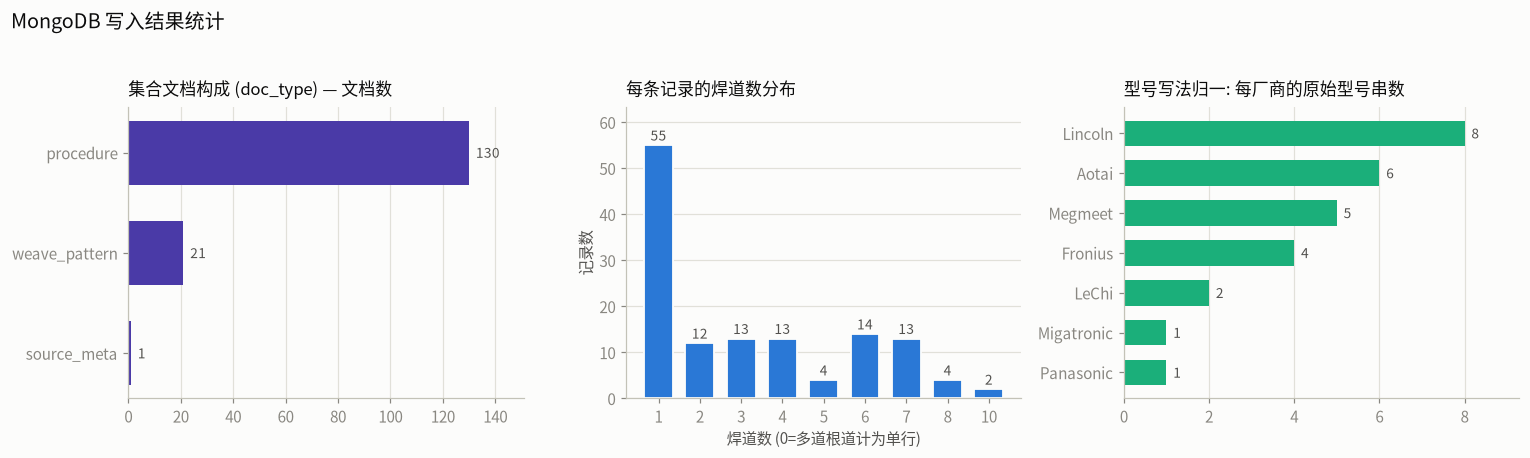

In [7]:
comp = pd.Series({t: n[t] for t in ["procedure", "weave_pattern", "source_meta"]})
npass = pd.Series([d["n_passes"] for d in procs]).value_counts().sort_index()
mfr_variants = {}
for d in procs:
    mfr_variants.setdefault(d["machine"]["manufacturer"], set()).add(d["machine"]["model_raw"])
variants = pd.Series({k: len(v) for k, v in mfr_variants.items()})

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
barh(axes[0], comp, "集合文档构成 (doc_type) — 文档数", color=C[4])

axes[1].bar(npass.index.astype(str), npass.values, color=C[0], width=0.7, edgecolor="#fcfcfb", linewidth=1.2)
for x, v in zip(range(len(npass)), npass.values):
    axes[1].text(x, v + 1, str(v), ha="center", color=INK2, fontsize=9)
axes[1].set_ylim(0, npass.max() * 1.15); axes[1].grid(axis="x", visible=False)
style_ax(axes[1], title="每条记录的焊道数分布", xlabel="焊道数 (0=多道根道计为单行)", ylabel="记录数")

barh(axes[2], variants, "型号写法归一: 每厂商的原始型号串数", color=C[1])
fig.suptitle("MongoDB 写入结果统计", color=INK, x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### 6.1 焊道数值字段统计与分布

解析后数值字段 (`current_A` / `voltage_V` / `travel_speed_mm_s` / `heat_input_J_mm`) 的描述统计与直方图。


,count,mean,std,min,10%,50%,90%,max
current_A,417.0,309.47,100.17,60.00,200.00,280.00,450.00,530.00
voltage_V,399.0,27.13,5.79,0.00,23.00,29.00,30.50,33.00
travel_speed_mm_s,416.0,5.18,1.95,1.10,2.60,5.00,7.50,15.00
heat_input_kJ_mm,395.0,1.84,1.01,0.03,0.92,1.63,2.85,7.04


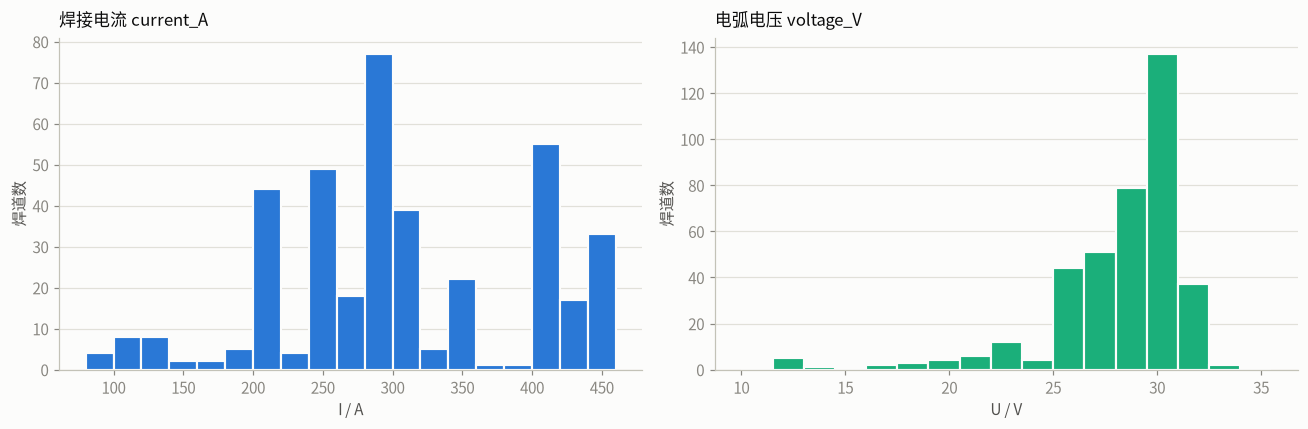

In [8]:
num = pf[["current_A", "voltage_V", "travel_speed_mm_s", "heat_input_J_mm"]].copy()
num["heat_input_kJ_mm"] = num.pop("heat_input_J_mm") / 1000
desc = num.describe(percentiles=[.1, .5, .9]).T[["count", "mean", "std", "min", "10%", "50%", "90%", "max"]]
display(desc.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pf["current_A"].dropna(), bins=np.arange(80, 470, 20), color=C[0],
             edgecolor="#fcfcfb", linewidth=1.4)
style_ax(axes[0], title="焊接电流 current_A", xlabel="I / A", ylabel="焊道数")
axes[1].hist(pf["voltage_V"].dropna(), bins=np.arange(10, 36, 1.5), color=C[1],
             edgecolor="#fcfcfb", linewidth=1.4)
style_ax(axes[1], title="电弧电压 voltage_V", xlabel="U / V", ylabel="焊道数")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 7. 从 MongoDB 查询回来校验

写入后直接对集合发聚合/查询, 证明文档模型可用 (与 mongosh 检查一致)。


In [9]:
print("== 按母材统计平均电流 (unwind passes, 过滤 80–450 A) ==")
for r in coll.aggregate([
    {"$match": {"doc_type": "procedure"}}, {"$unwind": "$passes"},
    {"$match": {"passes.current_A": {"$gte": 80, "$lte": 450}}},
    {"$group": {"_id": "$base_metal", "n": {"$sum": 1}, "avg_I": {"$avg": "$passes.current_A"}}},
    {"$sort": {"n": -1}}]):
    print(f"  {r['_id']:4s}  焊道 {r['n']:3d}  平均电流 {r['avg_I']:.0f} A")

print("\n== 用 passes.current_A 索引取高电流工艺 (>=440 A) ==")
hi = coll.count_documents({"passes.current_A": {"$gte": 440}})
print(f"  含 ≥440 A 焊道的记录数: {hi}")

print("\n== 摆动库路点回读 (pattern 107) ==")
wp = coll.find_one({"doc_type": "weave_pattern", "pattern_id": 107})
print("  waypoints:", [(w["point"], w["time_pct"], w["y_pct"]) for w in wp["waypoints"]])

== 按母材统计平均电流 (unwind passes, 过滤 80–450 A) ==
  碳钢    焊道 382  平均电流 303 A
  铸铁    焊道   6  平均电流 222 A
  不锈钢   焊道   5  平均电流 102 A
  铝合金   焊道   1  平均电流 130 A

== 用 passes.current_A 索引取高电流工艺 (>=440 A) ==
  含 ≥440 A 焊道的记录数: 24

== 摆动库路点回读 (pattern 107) ==
  waypoints: [(1, 25, 50), (2, 50, 0), (3, 75, -50)]


## 8. 小结

本 notebook 完整复现了 `project_data/ingest_mongo.py` 的导入管线, 并在每步加了统计/可视化:

- **解析**: `current_raw` 五类格式 (纯数值 / 括号送丝(实际A) / 双丝主-从 / 区间 / 缺失) 统一清洗为 `current_A`; 电压去单位并把"一元化"置空。
- **文档模型**: 130 条 `procedure` (内嵌 417 焊道, 保留 `*_raw` 原值) + 21 条 `weave_pattern` + 1 条 `source_meta`, 共 152 文档。
- **写入**: `drop`+`insert_many` 幂等重建, 建 3 个索引 (`doc_type`; `base_metal`+`machine.manufacturer`; `passes.current_A`)。
- **数据质量**: 电流/速度/摆动字段解析产出 ~≥95%, 电压 ~85% (扣除一元化), 线热输入受三者共同约束略低。
- **校验**: 聚合按母材算平均电流、索引取高电流工艺、回读摆动路点均正常。

要重跑导入 (数据修订后), 直接从上到下执行本 notebook, 或运行 `uv run python project_data/ingest_mongo.py`;
纯读回可视化见 [`welding_parameter_database_exploration.ipynb`](welding_parameter_database_exploration.ipynb)。
